# Meta-learning for few-shot domain adaptation (MAML)

The last stage. We adapt a model to a NEW domain - real YouTube clips - from only a few shots,
and test whether meta-learning helps.

The model here is the STRONG stage-2 ResNet50 trained on the base 10 UCF101 classes (~93%). The
YouTube classes (HorseRiding, Drumming, PushUps) are all in those 10, so its features are solid -
a fair stage for MAML. To keep the few-shot test HONEST we use SEVERAL videos per class and split
them VIDEO-DISJOINT: adapt on clips from one video, then test on the SAME video ("old") and on the
class's OTHER, held-out videos ("new"). Generalising to the NEW videos is the real test.

Both arms start from the same ResNet50 and few-shot adapt the same way; only MAML additionally
meta-trains over UCF101 episodes. If meta-learning helps, MAML wins on the NEW videos.

## **Connect Colab**

In [1]:
import os, sys, subprocess
from getpass import getpass

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "real-video"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [2]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "KEY"

## **Download DATASET**

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Drive mounted.
Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
ULAL_DATASET_ROOT = /kaggle/input/ucf101-action-recognition/
ULAL_OUTPUT_ROOT  = /kaggle/working/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [4]:
!pip install -q yt-dlp

In [5]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
Classes   : base=10 task1=5 task2=5


42

## **Setup**

In [6]:
K_SHOT   = 5
K_QUERY  = 5
EVAL_DRAWS = 10          # random video-disjoint draws; both arms averaged over the SAME ones
CLIPS_PER_VIDEO = 12     # clips per video (kept modest: ResNet50 is heavy on a T4)

META_EPOCHS   = 5        # episodic meta-training (MAML arm only)
META_EPISODES = 30       # ResNet50 is heavier than the student - keep episodes modest
INNER_LR      = 0.01
INNER_STEPS   = 5
META_LR       = 1e-4     # gentle: a large meta-lr degrades the strong ResNet50 init
# N_WAY is set after the YouTube download, from the classes that actually downloaded
print(f"{K_SHOT}-shot | {EVAL_DRAWS} draws | {CLIPS_PER_VIDEO} clips/video")

5-shot | 10 draws | 20 clips/video


## **Preprocess data**

Base 10 classes only - the stage-2 ResNet50 was trained on exactly these.

In [7]:
base_split = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)

In [8]:
# BASE  (max_samples caps TRAIN clips/class via cfg.MAX_SAMPLES; None = full data, val/test untouched)
preprocess_group_split(base_split, cfg.SELECTED_CLASSES, output_root=cfg.BASE_ROOT, max_samples=cfg.MAX_SAMPLES)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_base


In [9]:
class_to_idx = {cls_name: i for i, cls_name in enumerate(cfg.SELECTED_CLASSES)}
print(f"{len(cfg.SELECTED_CLASSES)} base classes")

10 base classes


## **Create Loaders**

A base-10 test loader (in-domain check) and a RAM pool for the meta-training episodes.

In [10]:
base_train = UCF101Clips(os.path.join(cfg.BASE_ROOT, "train"), class_to_idx=class_to_idx)
base_test  = UCF101Clips(os.path.join(cfg.BASE_ROOT, "test"),  class_to_idx=class_to_idx)
test_loader = DataLoader(base_test, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

In [11]:
pool_clips, pool_labels = build_pool([base_train], per_class=20)
class_pool = sorted(set(pool_labels.tolist()))
print(f"pool {tuple(pool_clips.shape)}  classes {len(class_pool)}")

pool (200, 16, 3, 224, 224)  classes 10


## **Load the ResNet50 (trained on the base 10, ~93%)**

Instead of the small distilled student, use the strong stage-2 ResNet50 as the shared init. Its
backbone + LSTM already know these classes well. (Run backbone_transfer first so the checkpoint
exists in Drive.)

In [12]:
set_seed(cfg.SEED)
base_model = ResNet50LSTM(num_classes=len(cfg.SELECTED_CLASSES)).to(device)
base_model.load_state_dict(torch.load(cfg.RESNET50_PATH, map_location=device))
print("loaded stage-2 ResNet50 (base-10 teacher)")

loaded stage-2 ResNet50 (base-10 teacher)


## **Test it on the base-10 UCF101**

In [13]:
acc_ucf, preds_ucf, labels_ucf = test_model(base_model, test_loader, device)
print(f"ResNet50 base-10 test accuracy: {acc_ucf:.4f}")

Test Accuracy: 0.9387
ResNet50 base-10 test accuracy: 0.9387


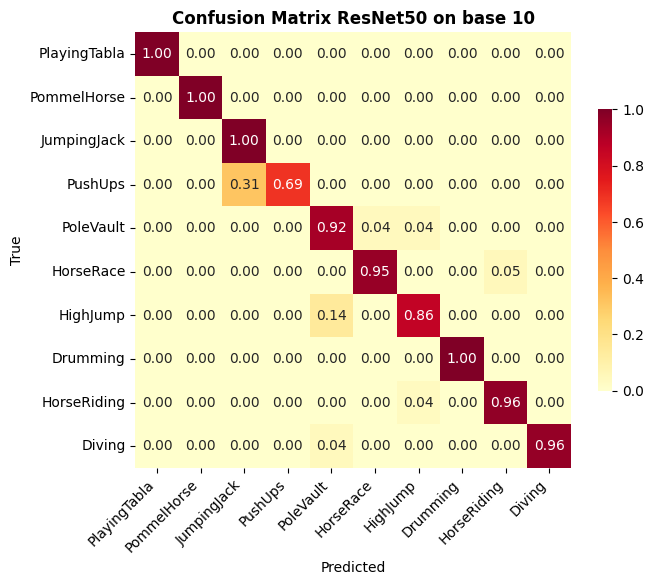

In [14]:
plot_confusion_matrix(labels_ucf, preds_ucf, num_classes=len(cfg.SELECTED_CLASSES), classes_list=cfg.SELECTED_CLASSES, name="ResNet50 on base 10")

## **YouTube few-shot task (several videos per class)**

Download every video for each class (clips spread across the whole video) and tag each clip with
its source video. A class needs >=2 videos to get a real "new video" test.

In [15]:
yt_clips, yt_labels, yt_videos = download_youtube_clips(cfg.YOUTUBE_CLIPS, class_to_idx, clips_per_video=CLIPS_PER_VIDEO)
yt_ids = sorted(set(yt_labels.tolist()))
N_WAY  = len(yt_ids)
for c in yt_ids:
    nv = len(set(yt_videos[yt_labels == c].tolist()))
    print(f"  {cfg.SELECTED_CLASSES[c]:<16}: {nv} video(s)")
print(f"{N_WAY}-way task  (classes with >=2 videos give a real new-video test)")

  HorseRiding video 0: 20 clips
  HorseRiding video 1: 20 clips
  HorseRiding video 2: 20 clips
  HorseRiding     : 3 usable video(s)
  Drumming video 0: 20 clips
  Drumming video 1: 20 clips
  Drumming video 2: 20 clips
  Drumming        : 3 usable video(s)
  PushUps video 0: 20 clips
  PushUps video 1: 20 clips
  PushUps video 2: 20 clips
  PushUps         : 3 usable video(s)
  PushUps         : 3 video(s)
  Drumming        : 3 video(s)
  HorseRiding     : 3 video(s)
3-way task  (classes with >=2 videos give a real new-video test)


## **Common init**

Give the ResNet50 a fresh N-way head for the YouTube classes. Both arms copy this exact model, so
they start identical - the only later difference is the meta-training.

In [16]:
import copy
init_model = copy.deepcopy(base_model)
init_model.fc = nn.Linear(cfg.HIDDEN_SIZE, N_WAY).to(device)
print(init_model.fc)

Linear(in_features=256, out_features=3, bias=True)


## **Adaptation WITHOUT MAML (no meta)**

Few-shot adapt the shared init on K_SHOT support clips from one video per class, then score the
query - split into OLD (same video) and NEW (held-out videos). Repeated over EVAL_DRAWS
video-disjoint draws; each draw is seeded so the MAML arm sees the exact same clips.

In [17]:
base_old, base_new = [], []
for d in range(EVAL_DRAWS):
    set_seed(cfg.SEED + d)     # draw d reproducible + identical in the MAML arm
    sx, sy, qx, qy, q_new = make_video_disjoint_task(yt_clips, yt_labels, yt_videos, yt_ids, K_SHOT, device)
    o, n = few_shot_old_new(copy.deepcopy(init_model), sx, sy, qx, qy, q_new, INNER_LR, INNER_STEPS, N_WAY)
    base_old.append(o); base_new.append(n)
    torch.cuda.empty_cache()
print(f"no-meta  old {np.nanmean(base_old):.3f}  |  new {np.nanmean(base_new):.3f}")

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


OutOfMemoryError: CUDA out of memory. Tried to allocate 7.90 GiB. GPU 0 has a total capacity of 14.56 GiB of which 4.33 GiB is free. Including non-PyTorch memory, this process has 10.23 GiB memory in use. Of the allocated memory 9.98 GiB is allocated by PyTorch, and 116.20 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

## **Adaptation WITH MAML**

Same shared init, but first meta-train it over UCF101 episodes. A gentle META_LR and a frozen
backbone keep the ResNet50 features intact (only the LSTM + head are meta-learned). Then few-shot
adapt to the SAME video-disjoint draws and score.

In [ ]:
set_seed(cfg.SEED)
maml_model = copy.deepcopy(init_model)
maml_model, hist_maml = meta_train_maml(maml_model, pool_clips, pool_labels, class_pool,
                                        N_WAY, K_SHOT, K_QUERY, META_EPOCHS, META_EPISODES,
                                        INNER_LR, INNER_STEPS, META_LR, device,
                                        freeze_backbone=True)

In [ ]:
maml_old, maml_new = [], []
for d in range(EVAL_DRAWS):
    set_seed(cfg.SEED + d)     # SAME seed per draw -> SAME support/query as the no-meta arm
    sx, sy, qx, qy, q_new = make_video_disjoint_task(yt_clips, yt_labels, yt_videos, yt_ids, K_SHOT, device)
    o, n = few_shot_old_new(copy.deepcopy(maml_model), sx, sy, qx, qy, q_new, INNER_LR, INNER_STEPS, N_WAY)
    maml_old.append(o); maml_new.append(n)
    torch.cuda.empty_cache()
print(f"MAML     old {np.nanmean(maml_old):.3f}  |  new {np.nanmean(maml_new):.3f}")
print(f"MAML gain on NEW videos: {np.nanmean(maml_new) - np.nanmean(base_new):+.3f}")

## **Training history (MAML meta-training)**

How the meta-training query accuracy improves over the UCF101 episodes - MAML learning to adapt fast.

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, META_EPOCHS + 1), hist_maml["query_accs"], marker="s")
plt.xlabel("meta epoch"); plt.ylabel("meta query accuracy"); plt.ylim(0, 1.05)
plt.title("MAML meta-training progress (UCF101 episodes)")
plt.tight_layout(); plt.show()

## **Compare: old vs new videos, per method and per class**

Per-class accuracy on OLD (seen) vs NEW (held-out) videos for each method. Both arms should do well
on OLD; on NEW videos - the real test - MAML's meta-trained init should pull ahead.

In [ ]:
class_names = [cfg.SELECTED_CLASSES[c] for c in yt_ids]
base_old_pc = [float(np.nanmean([r[c] for r in base_old])) for c in range(N_WAY)]
base_new_pc = [float(np.nanmean([r[c] for r in base_new])) for c in range(N_WAY)]
maml_old_pc = [float(np.nanmean([r[c] for r in maml_old])) for c in range(N_WAY)]
maml_new_pc = [float(np.nanmean([r[c] for r in maml_new])) for c in range(N_WAY)]
print(f"{'class':<16}{'no-meta old':>13}{'no-meta new':>13}{'MAML old':>11}{'MAML new':>11}")
for c in range(N_WAY):
    print(f"{class_names[c]:<16}{base_old_pc[c]:>13.3f}{base_new_pc[c]:>13.3f}{maml_old_pc[c]:>11.3f}{maml_new_pc[c]:>11.3f}")

In [ ]:
plot_old_vs_new(class_names, base_old_pc, base_new_pc, maml_old_pc, maml_new_pc, k_shot=K_SHOT)

## **Save**

In [ ]:
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
payload = {"n_way": N_WAY, "k_shot": K_SHOT, "eval_draws": EVAL_DRAWS,
           "shared_init": "resnet50_base10", "resnet_base10_test_acc": acc_ucf,
           "classes": class_names,
           "no_meta_old": base_old_pc, "no_meta_new": base_new_pc,
           "maml_old": maml_old_pc, "maml_new": maml_new_pc,
           "maml_curve": hist_maml["query_accs"]}
with open(f"{cfg.RESULTS_DIR}/stage5_meta_domain_adapt.json", "w") as f:
    json.dump(payload, f, indent=2)
print(f"saved -> {cfg.RESULTS_DIR}/stage5_meta_domain_adapt.json")